In [39]:
import pandas as pd
df = pd.read_csv("../data/raw/synthetic_mmm_weekly_india_SAT.csv",
               parse_dates=["Week"])
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11232 entries, 0 to 11231
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week                     11232 non-null  datetime64[ns]
 1   Geo                      11232 non-null  object        
 2   Brand                    11232 non-null  object        
 3   SKU                      11232 non-null  object        
 4   Sales_Units              11232 non-null  float64       
 5   Sales_Value              11232 non-null  float64       
 6   MRP                      11232 non-null  float64       
 7   Net_Price                11232 non-null  float64       
 8   Feature_Flag             11232 non-null  int64         
 9   Display_Flag             11232 non-null  int64         
 10  TPR_Flag                 11232 non-null  int64         
 11  Trade_Spend              11232 non-null  float64       
 12  TV_Impressions           11232 n

,Week,Geo,Brand,SKU,Sales_Units,Sales_Value,MRP,Net_Price,Feature_Flag,Display_Flag,...,FB_Banner_Content_Score,IG_Banner_Content_Score,Weighted_Distribution,Numeric_Distribution,TDP,NOS,CPI,GDP_Growth,Festival_Index,Rainfall_Index
0,2022-07-02,CENTRAL,BrandA,BrandA_SKU1,166.737425,15058.472804,90.312495,90.312495,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
1,2022-07-02,CENTRAL,BrandA,BrandA_SKU2,123.326990,11166.439172,90.543353,90.543353,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
2,2022-07-02,CENTRAL,BrandA,BrandA_SKU3,74.232953,7829.352426,105.470039,105.470039,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
3,2022-07-02,CENTRAL,BrandB,BrandB_SKU1,216.583770,15986.585046,73.812479,73.812479,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
4,2022-07-02,CENTRAL,BrandB,BrandB_SKU2,272.920195,22565.283219,82.680885,82.680885,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544


In [40]:
geo_brand = (
  df.groupby(["Week","Geo","Brand"], as_index=False)
    .sum(numeric_only=True)
)

In [41]:
import numpy as np
m = geo_brand.copy()
m["log_sales_val"] = np.log1p(m["Sales_Value"])
m["price_index"] = m["Net_Price"] / m.groupby(["Geo","Brand"])["Net_Price"].transform("mean")


In [42]:
df["Week_Start"] = df["Week"] - pd.Timedelta(days=6)

In [43]:
# Market-calibrated CPMs for India (2024-2025 benchmarks)
RESEARCHED_CPMS = {
    'TV': 60,           # Efficient mass reach
    'YouTube': 250,      # Premium video inventory
    'Facebook': 110,     # Broad social reach
    'Instagram': 180     # Premium social engagement
}


# Calculate Spend using researched CPM benchmarks
# We divide by 1000 to turn Impressions into "Units of 1000"
m['TV_Spend'] = (m['TV_Impressions'] / 1000) * RESEARCHED_CPMS['TV']
m['YouTube_Spend'] = (m['YouTube_Impressions'] / 1000) * RESEARCHED_CPMS['YouTube']
m['Facebook_Spend'] = (m['Facebook_Impressions'] / 1000) * RESEARCHED_CPMS['Facebook']
m['Instagram_Spend'] = (m['Instagram_Impressions'] / 1000) * RESEARCHED_CPMS['Instagram']

# Final Marketing Spend Calculation
marketing_channels = ['TV_Spend', 'YouTube_Spend', 'Facebook_Spend', 'Instagram_Spend', 'Trade_Spend']
m['Total_Spend'] = m[marketing_channels].sum(axis=1)

#ROI calculation
m['naive_roi'] = m['Sales_Value'] / (m['Total_Spend'] + 1e-6)

#creating lagged features
# Create lagged features on 'm' instead of 'df'
m['TV_Spend_Lag1'] = m['TV_Spend'].shift(1)
m['YouTube_Spend_Lag1'] = m['YouTube_Spend'].shift(1)
m['Facebook_Spend_Lag1'] = m['Facebook_Spend'].shift(1)
m['Instagram_Spend_Lag1'] = m['Instagram_Spend'].shift(1)

# Essential: Handle the NaNs created by shifting
m.fillna(0, inplace=True)


print(m[['Brand', 'Sales_Value', 'Total_Spend', 'naive_roi']].head())

    Brand   Sales_Value    Total_Spend  naive_roi
0  BrandA  34054.264402  627715.285505   0.054251
1  BrandB  43537.095662  488580.711940   0.089109
2  BrandC  15606.889435  287388.376291   0.054306
3  BrandA  53794.394906  525587.960864   0.102351
4  BrandB  39371.341028  584820.804719   0.067322


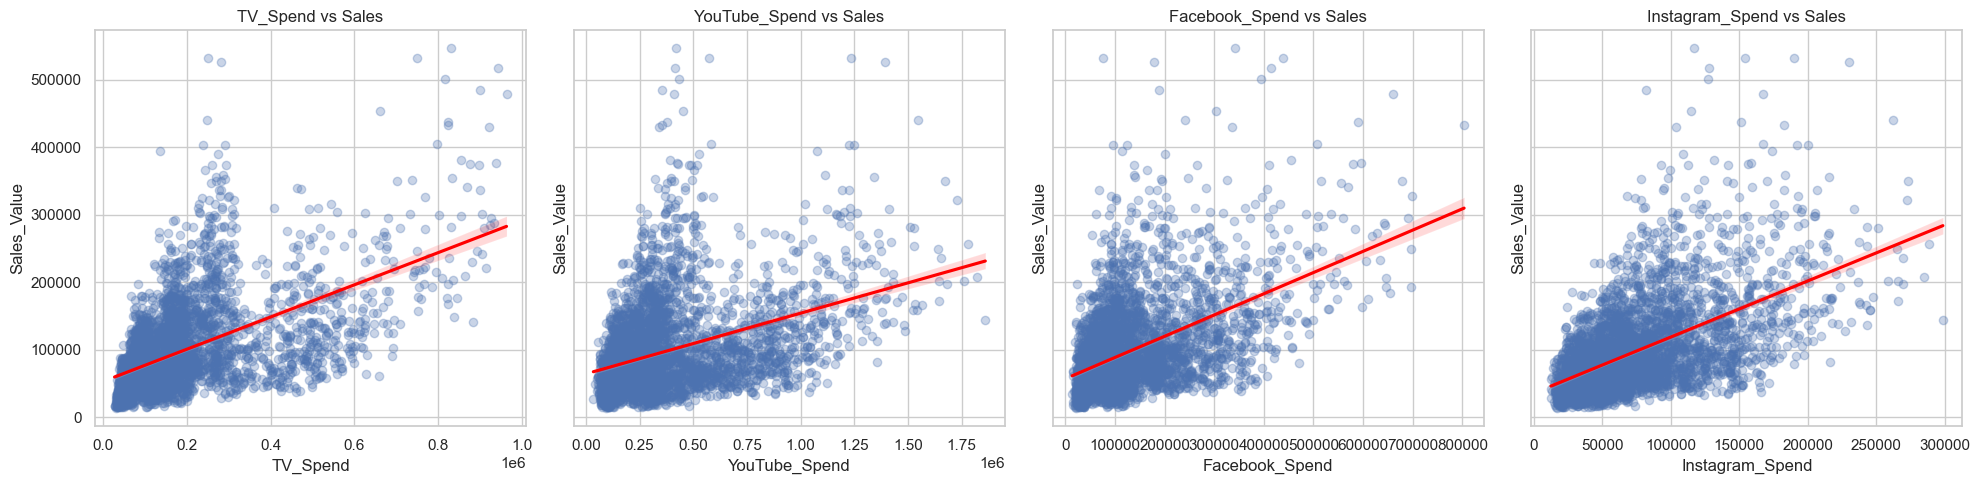

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style
sns.set_theme(style="whitegrid")

# Create a figure with subplots for each channel
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

channels = ['TV_Spend', 'YouTube_Spend', 'Facebook_Spend', 'Instagram_Spend']

for i, col in enumerate(channels):
    sns.regplot(x=col, y='Sales_Value', data=m, ax=axes[i], 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Sales')

plt.tight_layout()
plt.show()

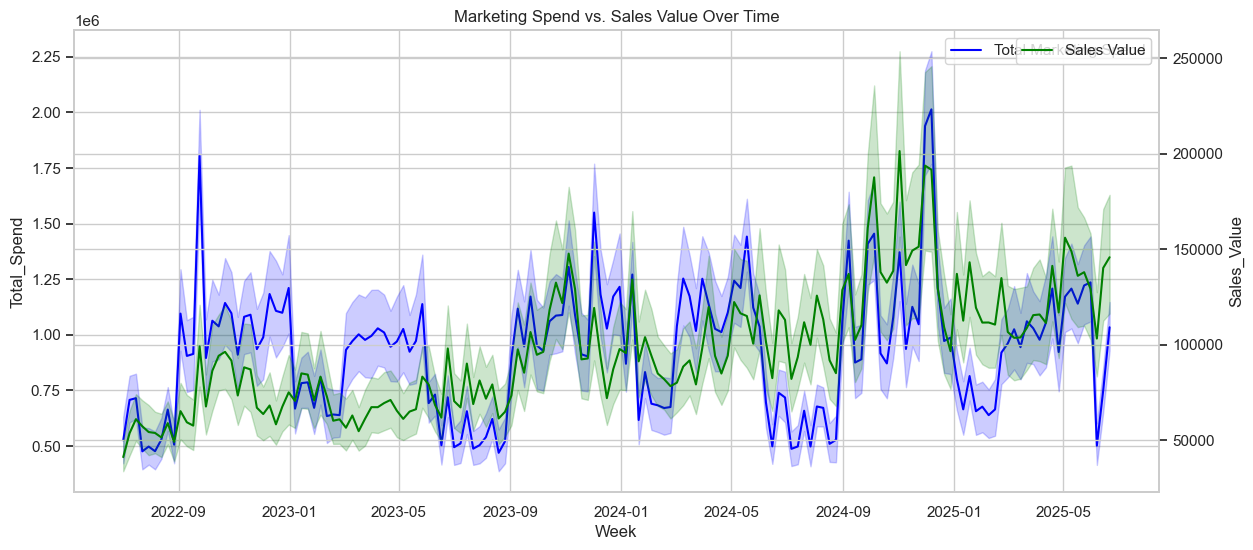

In [45]:
plt.figure(figsize=(14, 6))

# Plot Total Spend
sns.lineplot(data=m, x='Week', y='Total_Spend', label='Total Marketing Spend', color='blue')

# Create a second y-axis for Sales
ax2 = plt.twinx()
sns.lineplot(data=m, x='Week', y='Sales_Value', label='Sales Value', color='green', ax=ax2)

plt.title('Marketing Spend vs. Sales Value Over Time')
plt.show()

In [46]:
#export processed data

m.to_csv("../data/processed/cleaned_marketing_data.csv", index=False)